In [13]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Tuple
from tqdm import tqdm
from voluntary_fixation.behavior.src.probability import prob_sacc_on_multiple_saliency
from voluntary_fixation.behavior.src.data_loader import read_csvs
from voluntary_fixation.envs import MOVIE_FPS, MOVIE_HEIGHT, MOVIE_WIDTH, SAVE_ROOT


In [14]:
# PAPER_FPS = 25
VIDEO_FPS = 30
EYE_FPS = 1000
VIDEO_HEIGHT = 720
VIDEO_WIDTH = 1280

salieny_csv_root = '../../../../results/srm/saliency_prediction2/deepgaze2e'
saliency_csv_file_path_pattern = 'segment-{run_id}.csv'

eyetrack_csv_root = '../../../../results/srm/shift_prediction2/eyemove_csv'
eyetrack_csv_file_path_pattern = 'sub-{sub}_run-{run_id}.csv'

original_eyetrack_root = '../../../../data/forrestgump/studyforrest/annot/studyforrest-data-eyemovementlabels'
original_eyetrack_path_pattern = 'sub-{sub}/sub-{sub}_task-movie_run-{run_id}_events.tsv'

gaze_shift_label = ['FIXA', 'PURS']# ['SACC']
TR=2
run_trs = [451, 441, 438, 488, 462, 439, 542, 338]

save_root = '../../results/srm/saliency_gaze/eyemove_saliency'
os.makedirs(save_root, exist_ok=True)

run_ids = [1,2,3,4,5,6,7,8]
sbjs = ['01','02','03','04','06','10','14', '15', '16', '17', '18', '19']
saliency_qs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]# [0.5, 1, 2, 3, 4]
colors = ['r', 'g', 'b', 'k', 'c', 'm', 'y', 'orange', 'purple', 'brown']
sacc_th_q = 0.5

In [15]:
# load_data
csv_path = os.path.join(save_root, f'sacc_with_saliency-sacc_q{sacc_th_q}-{"_".join(gaze_shift_label)}.csv')
if False: #os.path.exists(csv_path):
    prob_dfs = pd.read_csv(csv_path)
else:
    prob_dfs:List[pd.DataFrame] = []
    for sbj in tqdm(sbjs):
        for run_id in run_ids:
            saliency_csv_file_path = os.path.join(salieny_csv_root, saliency_csv_file_path_pattern.format(run_id=run_id))
            eyetrack_csv_file_path = os.path.join(eyetrack_csv_root, eyetrack_csv_file_path_pattern.format(sub=sbj, run_id=run_id))
            original_eyetrack_path = os.path.join(original_eyetrack_root, original_eyetrack_path_pattern.format(sub=sbj, run_id=run_id))

            saliency_df, original_eyetrack_df = read_csvs(saliency_csv_file_path,
                                                            original_eyetrack_path, gaze_shift_label,
                                                            video_width=MOVIE_WIDTH,
                                                            video_height=MOVIE_HEIGHT, fps=MOVIE_FPS)
            # calc sacc probability on saliency
            prob_df = prob_sacc_on_multiple_saliency(saliency_df, original_eyetrack_df,
                                saliency_qs, gaze_shift_label, sacc_th_q=sacc_th_q, have_duration=False)

            prob_df['sbj'] = [sbj] * len(prob_df)
            prob_df['run_id'] = [run_id] * len(prob_df)

            prob_dfs.append(prob_df)
    prob_dfs = pd.concat(prob_dfs, axis=0)
    prob_dfs.to_csv(csv_path, index=False)
    print('save as ', csv_path)


  0%|          | 0/12 [00:00<?, ?it/s]

saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column


  8%|▊         | 1/12 [01:59<21:58, 119.91s/it]

saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column


 17%|█▋        | 2/12 [03:58<19:49, 118.92s/it]

...

saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column


 92%|█████████▏| 11/12 [21:37<01:59, 119.61s/it]

saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column
saliency_df has no duration column


100%|██████████| 12/12 [23:36<00:00, 118.01s/it]

save as  ../../results/srm/saliency_gaze/eyemove_saliency/sacc_with_saliency-sacc_q0.5-FIXA_PURS.csv


In [20]:
prob_dfs

,saliency_q_cnt,sal_label,q,SACC_cnt,SACC_cnt_large,SACC_cnt_on_sal,SACC_cnt_large_on_sal,sbj,run_id
0,18224,max_shift_norm,0.1,12011,5734,0.659076,0.314640,1,1
1,18224,max_shift_norm,0.2,12011,5734,0.659076,0.314640,1,1
2,18224,max_shift_norm,0.3,12011,5734,0.659076,0.314640,1,1
3,11528,max_shift_norm,0.4,7653,3611,0.663862,0.313237,1,1
4,11528,max_shift_norm,0.5,7653,3611,0.663862,0.313237,1,1
...,...,...,...,...,...,...,...,...,...
2299,4056,avg_shift_norm,0.8,1936,949,0.477318,0.233974,19,8
2300,2028,avg_shift_norm,0.9,855,384,0.421598,0.189349,19,8
2301,1014,avg_shift_norm,0.95,358,167,0.353057,0.164694,19,8
2302,203,avg_shift_norm,0.99,72,31,0.354680,0.152709,19,8


In [21]:
sacc_th_q = 0.5
csv_path = os.path.join(save_root, f'sacc_with_saliency-sacc_q{sacc_th_q}-{"_".join(gaze_shift_label)}.csv')
prob_dfs = pd.read_csv(csv_path)

/tmp/ipykernel_1162127/2134776472.py:19: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  scores = q_df.mean()
/tmp/ipykernel_1162127/2134776472.py:20: FutureWarning: The default value of numeric_only in DataFrame.std is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  stds = q_df.std()
/tmp/ipykernel_1162127/2134776472.py:19: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  score

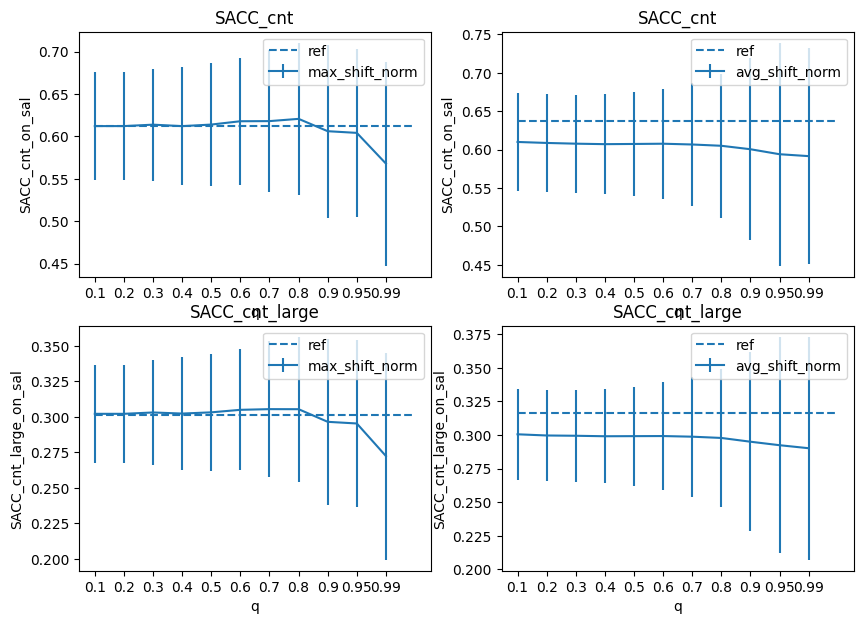

In [22]:

sal_labels = ['max_shift_norm', 'avg_shift_norm']
sacc_labels = ['SACC_cnt', 'SACC_cnt_large']
# all sbj :
df_qs = prob_dfs['q'].unique()
df_qs = np.sort(df_qs)

xticks_q = [q for q in df_qs if not('ref' in q) ]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for c, sal_label in enumerate(sal_labels):
    target_df = prob_dfs[prob_dfs['sal_label'] == sal_label]
    score_mean_qs = []
    score_std_qs = []
    for q in df_qs:
        q_df = target_df[target_df['q'] == q]
        if 'ref' in q:
            ref_scores = q_df.mean() # agg across sbj
            continue
        scores = q_df.mean()
        stds = q_df.std()
        score_mean_qs.append(scores)
        score_std_qs.append(stds)
    for r, sacc_label in enumerate(sacc_labels):
        means = [m[f'{sacc_label}_on_sal'] for m in score_mean_qs]
        stds = [m[f'{sacc_label}_on_sal'] for m in score_std_qs]

        axes[r, c].errorbar(xticks_q, means, yerr=stds, label=sal_label)
        axes[r,c].hlines(ref_scores[f'{sacc_label}_on_sal'], 0, len(xticks_q), linestyles='dashed', label='ref')
        axes[r,c].set_title(sacc_label)
        axes[r,c].set_xlabel('q')
        axes[r,c].set_ylabel(f'{sacc_label}_on_sal')
        axes[r,c].legend()
        axes[r,c].set_xticks(xticks_q)
plt.show()


/tmp/ipykernel_1162127/2149819400.py:29: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  scores = sbj_q_df.mean()
/tmp/ipykernel_1162127/2149819400.py:30: FutureWarning: The default value of numeric_only in DataFrame.std is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  stds = sbj_q_df.std()
/tmp/ipykernel_1162127/2149819400.py:29: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.

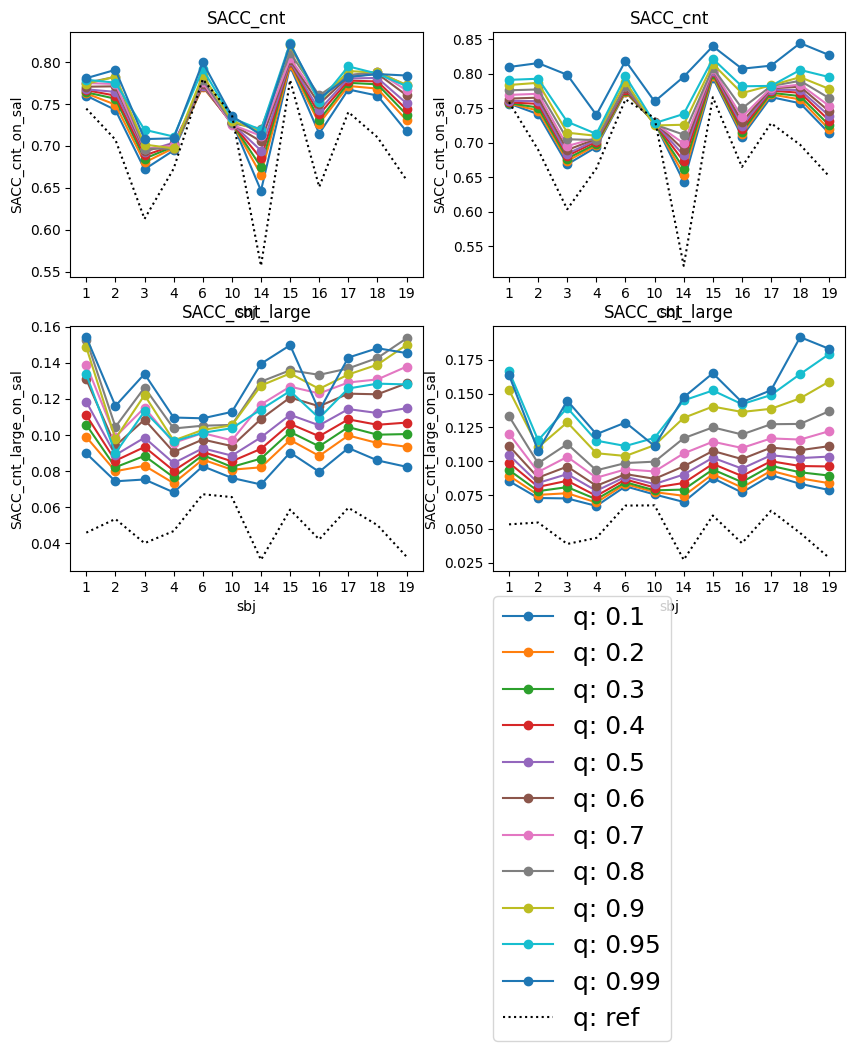

In [33]:
gaze_shift_label = ['FIXA', 'PURS']
sacc_th_q = 0.9
save_root = os.path.join('../../', SAVE_ROOT, 'behavior', 'find_q')
csv_path = os.path.join(save_root, f'gaze_shift_with_saliency-{"_".join(gaze_shift_label)}_q{sacc_th_q}.csv')
prob_dfs = pd.read_csv(csv_path)

sal_labels = ['max_shift_norm', 'avg_shift_norm']
sacc_labels = ['SACC_cnt', 'SACC_cnt_large']
# all sbj :
sbjs = prob_dfs['sbj'].unique()
sbjs = np.sort(sbjs)
sbj_xtics=list(range(len(sbjs)))
df_qs = prob_dfs['q'].unique()
df_qs = np.sort(df_qs)

# xticks_q = [q for q in df_qs if not('ref' in q) ]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

target_sal_q = 0.5
for c, sal_label in enumerate(sal_labels):
    target_df = prob_dfs[prob_dfs['sal_label'] == sal_label]
    for i, q in enumerate(df_qs):
        q_df = target_df[target_df['q'] == q]
        score_mean_sbjs = [] # sbj
        score_std_sbjs = [] # sbj
        for sbj in sbjs:
            sbj_q_df = q_df[q_df['sbj'] == sbj]

            scores = sbj_q_df.mean()
            stds = sbj_q_df.std()
            score_mean_sbjs.append(scores)
            score_std_sbjs.append(stds)
        for r, sacc_label in enumerate(sacc_labels):
            means = [m[f'{sacc_label}_on_sal'] for m in score_mean_sbjs]
            stds = [m[f'{sacc_label}_on_sal'] for m in score_std_sbjs]

            if 'ref' in q:
                axes[r,c].plot(sbj_xtics, means, 'k:', label=f'q: ref')
            else:
                axes[r,c].plot(sbj_xtics, means, 'o-', label=f'q: {q}')

            if sal_label == 'avg_shift_norm' and sacc_label == 'SACC_cnt_large':
                if 'ref' in q:
                    ref_probs = means
                else:
                    target_sal_probs = means


for c, sal_label in enumerate(sal_labels):
    for r, sacc_label in enumerate(sacc_labels):
        axes[r,c].set_title(sacc_label)
        axes[r,c].set_xlabel('sbj')
        axes[r,c].set_ylabel(f'{sacc_label}_on_sal')
        axes[r,c].set_xticks(sbj_xtics)
        axes[r,c].set_xticklabels(sbjs)

axes[r,c].legend(bbox_to_anchor=(0, -0.1), loc='upper left', borderaxespad=0, fontsize=18)
plt.show()




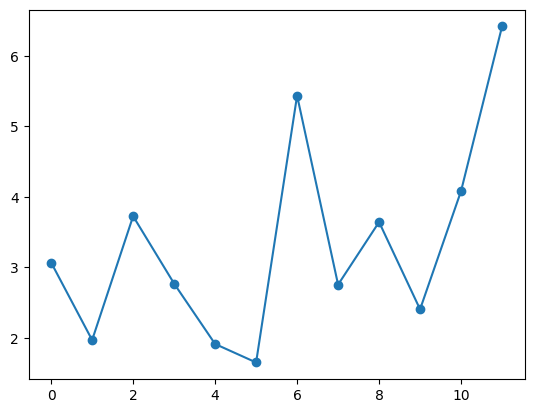

In [34]:
sbjs_probs = np.array(target_sal_probs) / np.array(ref_probs)
plt.plot(sbj_xtics, sbjs_probs, 'o-')

In [35]:
sbjs_probs

array([3.06911364, 1.96921811, 3.7266248 , 2.77037176, 1.91353002,
       1.65128471, 5.43727437, 2.75579996, 3.64363772, 2.4054216 ,
       4.0838853 , 6.4183944 ])